In [1]:
import os
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=4"
import jax
import jax_rmhd as jr
import jax.numpy as jnp
import jax.numpy.fft as ft
import matplotlib.pyplot as plt

#parameters
nx = 64
ny = 64
nz = 64
Lx = 2.0 * jnp.pi
Ly = 2.0 * jnp.pi
Lz = 2.0 * jnp.pi
t = 0.0
nsnap = 100
t_snap = 100
t_end = 5.0
cfl_safety = 0.5 
spatial_dimensions=3
snap_path="data/ot3d_v3"

#we will use hyperviscosity
visc=1e-5
res=1e-5
hyper=3

#prepare necessary objects for simulation
params=jr.Parameters(nx=nx,ny=ny,nz=nz,Lx=Lx,Ly=Ly,Lz=Lz,eqpars={'diss':(visc,res),'hyper':hyper},cfl_safety=cfl_safety,dims=spatial_dimensions)

mngr=jr.snapshot_manager_setup(params,snap_path=snap_path,nsnap=nsnap)
params.save(snap_path) #records params.json for later post-processing (see postprocessing.ipynb)
kgrid = jr.setup_kgrids(params)

def test_init(x,y,z):
    phi = (jnp.cos(x+1.4) + jnp.cos(y+0.5)) * jnp.sin(z)
    psi = (jnp.cos(2.0*x+2.3) + jnp.cos(y + 4.1)) * jnp.cos(z)
    return jnp.stack([phi,psi],axis=0)

state=jr.initialize(test_init,params)

nblock = jr.estimate_good_nblock(state,kgrid,params,t_snap,t_end,nblock_min=1)
print("nblock estimate: "+str(nblock)) #not actually using this, since we just want to simulate for a fixed 100 steps
nblock = 1

end_state=jr.simulate_scan(state,kgrid,params,nblock,t_snap=t_snap,t_end=t_end,mngr=mngr,save=True)

jax is using 64bit precision.
nblock estimate: 221
Saving initial state as snapshot 0 at t = 0.0
0.02260387082728548
0.04514398140244348
0.06766533946798733
0.09014365204973705
0.1125871177018365
0.13497861158131946
0.15730969297479175
0.17959420672818047
0.20184543414606734
0.2240652386195325
0.2462204652988555
0.2683194032937979
0.29037213370981063
0.31237333738478
0.33429709601980745
0.35615147443239586
0.3779437656943825
0.39968197179585263
0.42132382699787707
0.4428307521481544
0.4640989705905988
0.4851482510888482
0.5060211537277826
0.5266634988839748
0.5470820581546346
0.5673185682949057
0.5873284815690454
0.6070469327156762
0.6265055937799596
0.6457283027622194
0.6647521949758328
0.6835483341153282
0.7021115900424988
0.7204777885769675
0.7386532895475958
0.7566471810244368
0.7744835830500535
0.7921073855416637
0.8095419185481055
0.8268094849451055
0.8439310423233021
0.8609263431446407
0.8778140608975956
0.894611903923673
0.911336718332091
0.9280045812512729
0.9446308855227716
0

In [2]:
import jax_rmhd.snapshot_io as sn
#Making some snapshots.
for isnap in sn.get_saved_steps(snap_path):
    snap=sn.load_snapshot(isnap,snap_path,params)
    vort=ft.irfft2(-kgrid.ksq*snap.fields[0])
    plt.subplot(121)
    plt.imshow(vort[nz//2,:,:],vmin=-30,vmax=30,cmap="afmhot")
    plt.subplot(122)
    plt.imshow(vort[:,0,:],vmin=-30,vmax=30,cmap="afmhot")
    plt.savefig(snap_path+str(isnap).zfill(3)+".png")
    plt.close('all')
    

In [3]:
import jax_rmhd.snapshot_io as sn

isnap=1
snap=sn.load_snapshot(isnap,snap_path,params)
vort=ft.irfft2(-kgrid.ksq*snap.fields[0])
for iz in range(nz):
    plt.imshow(vort[iz,:,:],cmap="afmhot")
    plt.savefig(snap_path+"/slice"+str(iz).zfill(3)+".png")
    plt.close('all')

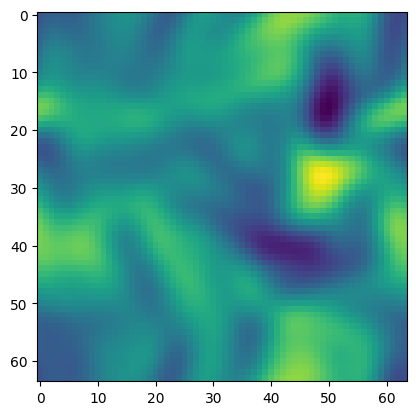

In [4]:
plt.imshow(vort[0,:,:])